<a href="https://colab.research.google.com/github/Prajkta11222/Market-Basket-Analysis-ML/blob/main/MARKET_BASKET_ML(CS23024%2CCS23031).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Market-Basket-Analysis-ML

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [34]:
import pandas as pd
url = "https://raw.githubusercontent.com/Prajkta11222/Market-Basket-Analysis-ML/main/Groceries_dataset.csv"
data = pd.read_csv(url)
data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [35]:
data.shape

(38765, 3)

In [36]:
transactions = data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

In [37]:
transactions[:5]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

In [38]:
!pip install mlxtend

In [39]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
te = TransactionEncoder()

te_data = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_data, columns=te.columns_)

df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [41]:
item_counts = df.sum().sort_values(ascending=False)

item_counts.head(10)

,0
whole milk,2363
other vegetables,1827
rolls/buns,1646
soda,1453
yogurt,1285
root vegetables,1041
tropical fruit,1014
bottled water,908
sausage,903
citrus fruit,795


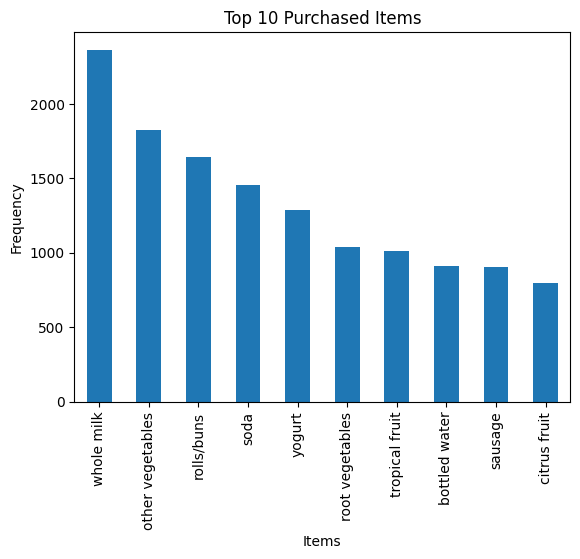

In [42]:
item_counts.head(10).plot(kind='bar')

plt.title("Top 10 Purchased Items")

plt.xlabel("Items")

plt.ylabel("Frequency")

plt.show()

Model 1: Apriori Algorithm

In [43]:
# Import Apriori and association rule functions
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore")

In [44]:
# Find frequent itemsets (items appearing in at least 1% transactions)
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)

In [45]:
# Show first few frequent itemsets
frequent_itemsets.head()

,support,itemsets
0,0.021386,(UHT-milk)
1,0.033950,(beef)
2,0.021787,(berries)
3,0.016574,(beverages)
4,0.045312,(bottled beer)


In [46]:
# Generate association rules using confidence metric
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

In [47]:
# Display top rules
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317


FP GROWTH


In [48]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import fpgrowth, association_rules

In [49]:
# Step 1: Apply FP-Growth algorithm
fp_items = fpgrowth(df, min_support=0.01, use_colnames=True)

In [50]:
# Display frequent itemsets
fp_items.head()

,support,itemsets
0,0.157923,(whole milk)
1,0.085879,(yogurt)
2,0.060349,(sausage)
3,0.051728,(pastry)
4,0.018780,(salty snack)


In [51]:
# Step 2: Show frequent itemsets
print("Frequent Itemsets:")
display(fp_items.head())

Frequent Itemsets:


,support,itemsets
0,0.157923,(whole milk)
1,0.085879,(yogurt)
2,0.060349,(sausage)
3,0.051728,(pastry)
4,0.018780,(salty snack)


In [52]:
# Step 3: Generate association rules
# Lowering the min_threshold for confidence to generate more rules
fp_rules = association_rules(fp_items, metric="confidence", min_threshold=0.1)

In [53]:
# Step 4: Show rules
print("\nAssociation Rules:")
print(fp_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Association Rules:
          antecedents   consequents   support  confidence      lift
0            (yogurt)  (whole milk)  0.011161    0.129961  0.822940
1              (soda)  (whole milk)  0.011629    0.119752  0.758296
2        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
3  (other vegetables)  (whole milk)  0.014837    0.121511  0.769430


In [54]:
# Step 5: Sort rules by lift (important)
fp_rules_sorted = fp_rules.sort_values(by="lift", ascending=False)

In [55]:
# Step 6: Show top 10 strong rules
print("\nTop 10 Rules by Lift:")
print(fp_rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Top 10 Rules by Lift:
          antecedents   consequents   support  confidence      lift
0            (yogurt)  (whole milk)  0.011161    0.129961  0.822940
2        (rolls/buns)  (whole milk)  0.013968    0.126974  0.804028
3  (other vegetables)  (whole milk)  0.014837    0.121511  0.769430
1              (soda)  (whole milk)  0.011629    0.119752  0.758296


Model 3: Eclat Algorithm

In [56]:
# Map each item to transaction IDs
item_dict = {}

for i, transaction in enumerate(transactions):
    for item in transaction:
        if item not in item_dict:
            item_dict[item] = set()
        item_dict[item].add(i)

In [57]:
min_support = 0.01 * len(transactions)

In [58]:
frequent_items = {}

for item, tids in item_dict.items():
    if len(tids) >= min_support:
        frequent_items[item] = len(tids)

In [59]:
frequent_items

{'sausage': 903,
 'whole milk': 2363,
 'yogurt': 1285,
 'pastry': 774,
 'salty snack': 281,
 'canned beer': 702,
 'misc. beverages': 236,
 'hygiene articles': 205,
 'soda': 1453,
 'frankfurter': 565,
 'curd': 504,
 'rolls/buns': 1646,
 'beef': 508,
 'white bread': 359,
 'whipped/sour cream': 654,
 'frozen vegetables': 419,
 'other vegetables': 1827,
 'butter': 527,
 'tropical fruit': 1014,
 'sugar': 265,
 'butter milk': 263,
 'specialty chocolate': 239,
 'root vegetables': 1041,
 'frozen meals': 251,
 'pip fruit': 734,
 'red/blush wine': 157,
 'chocolate': 353,
 'shopping bags': 712,
 'margarine': 482,
 'bottled water': 908,
 'chicken': 417,
 'bottled beer': 678,
 'hamburger meat': 327,
 'dessert': 353,
 'domestic eggs': 555,
 'white wine': 175,
 'herbs': 158,
 'newspapers': 582,
 'coffee': 473,
 'UHT-milk': 320,
 'sliced cheese': 210,
 'specialty bar': 209,
 'grapes': 216,
 'citrus fruit': 795,
 'candy': 215,
 'onions': 303,
 'brown bread': 563,
 'processed cheese': 152,
 'meat': 252,

Model 4: Association Rule Analysis

In [60]:
# Sort rules by confidence
rules_conf = rules.sort_values(by="confidence", ascending=False)

rules_conf.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694


In [75]:
strong_rules = rules[rules['lift'] > 0.5]

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317


In [76]:
strong_rules[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
1,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
2,(soda),(whole milk),0.011629,0.119752,0.758296
3,(yogurt),(whole milk),0.011161,0.129961,0.822940


In [77]:
strong_rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(yogurt),(whole milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
1,(rolls/buns),(whole milk),0.110005,0.157923,0.013968,0.126974,0.804028,1.0,-0.003404,0.964550,-0.214986,0.055000,-0.036752,0.107711
0,(other vegetables),(whole milk),0.122101,0.157923,0.014837,0.121511,0.769430,1.0,-0.004446,0.958551,-0.254477,0.055948,-0.043241,0.107730
2,(soda),(whole milk),0.097106,0.157923,0.011629,0.119752,0.758296,1.0,-0.003707,0.956636,-0.260917,0.047776,-0.045329,0.096694


Model 5 : K-Means Clustering

In [78]:
# Import KMeans
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [79]:
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [80]:
# Apply KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)

kmeans.fit(df)

# Get cluster labels
labels = kmeans.labels_

In [81]:
# Add cluster labels to dataset
df['Cluster'] = labels

df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback,Cluster
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,2
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,0
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0


In [82]:
# Count items in each cluster
df['Cluster'].value_counts()

,count
Cluster,
0,11693
1,1802
2,1468


In [83]:
df.groupby('Cluster').mean()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.004191,0.022492,0.001625,0.002053,0.000171,0.000342,0.008125,0.001283,0.037202,0.023262,...,0.005302,0.003763,0.019755,0.046866,0.000342,0.025400,0.012315,0.165398,0.089113,0.004191
1,0.003885,0.016093,0.001110,0.001110,0.000555,0.000000,0.006104,0.000555,0.024417,0.016648,...,0.008879,0.001665,0.015538,0.032741,0.001665,0.017758,0.007214,0.110433,0.062708,0.002775
2,0.002725,0.019074,0.000681,0.002044,0.000000,0.000000,0.010218,0.000681,0.019755,0.016349,...,0.001362,0.002725,0.012262,0.032016,0.000681,0.020436,0.012262,0.156676,0.088556,0.004087
